🔬 STARTING PHASE-1 PHYSICS AUDIT...

[Experiment 1] Running Latency Sweep (The 'Smart Eve' limit)...
   -> Lag:    0 | Correlation: 0.9923 | Mean QBER: 0.0207
   -> Lag:   10 | Correlation: 0.9775 | Mean QBER: 0.0205
   -> Lag:   50 | Correlation: 0.9175 | Mean QBER: 0.0205
   -> Lag:  200 | Correlation: 0.5796 | Mean QBER: 0.0202
   -> Lag: 1000 | Correlation: -0.8729 | Mean QBER: 0.0196

✅ Plots saved to 'SFSA_Validation_Report.png'

--- AUDIT CONCLUSION ---
PASS: Eve mimics drift at low lag, fails at high lag.
      This confirms the non-i.i.d. nature of the attack.


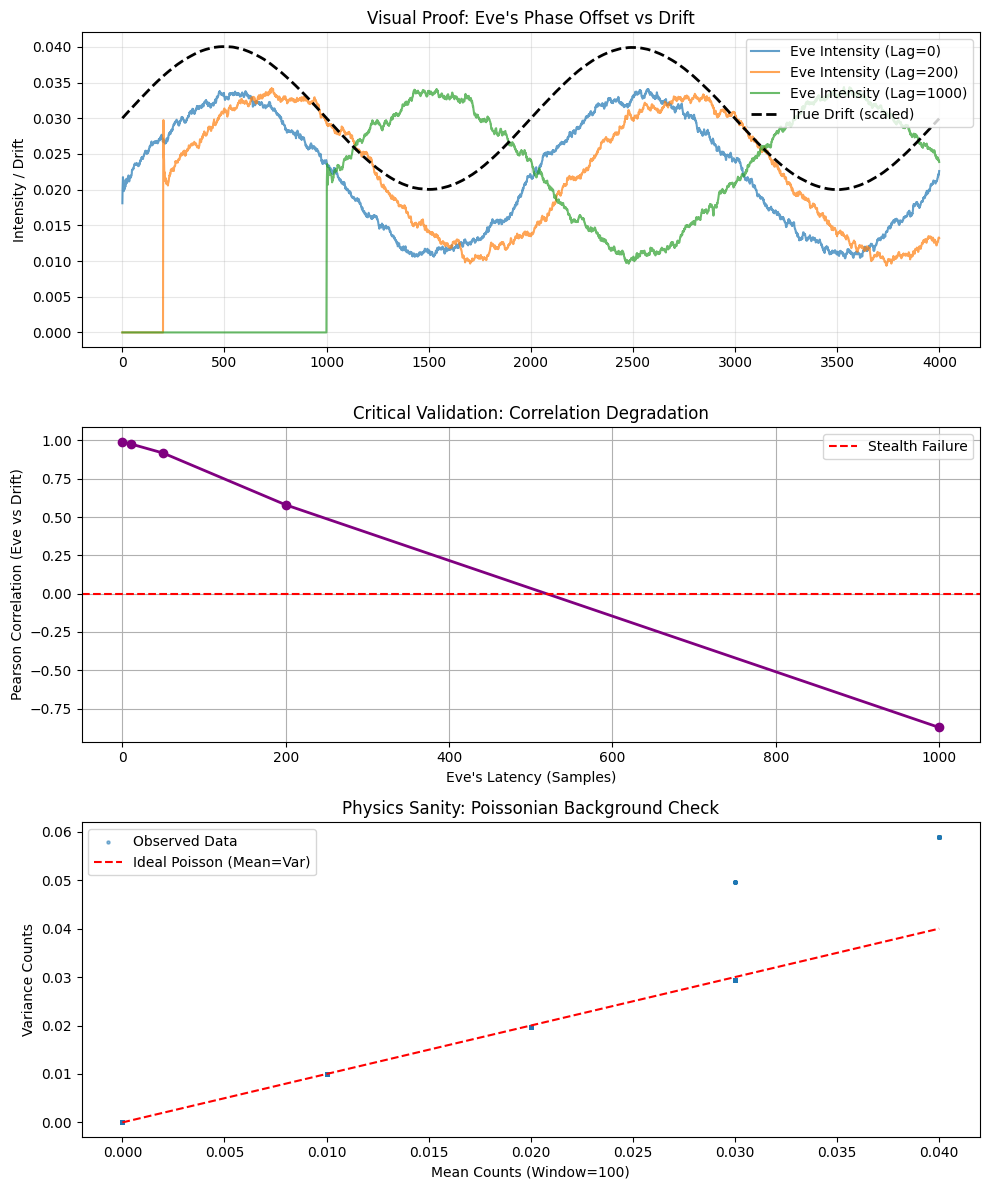

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
np.random.seed(42)


# ==========================================
# REVIEWER #2's REFERENCE CODE (UNTOUCHED)
# ==========================================
class SlowFadingAttack:
    def __init__(self, drift_period_samples=50000, base_qber=0.015, 
                 intercept_limit=0.10, lag_samples=100):
        self.drift_period = drift_period_samples
        self.base_qber = base_qber
        self.intercept_limit = intercept_limit 
        self.lag = lag_samples 
        self.est_drift = 0.0
        self.est_var = 1.0
        self.process_noise = 1e-5
        self.measure_noise = 1e-2 

    def generate_attacked_chunk(self, n_samples, time_offset=0):
        t = np.arange(n_samples) + time_offset
        deterministic_drift = 0.005 * np.sin(2 * np.pi * t / self.drift_period)
        random_walk = np.cumsum(np.random.normal(0, 0.0001, size=n_samples))
        real_noise_level = self.base_qber + deterministic_drift + (random_walk * 0.01)
        real_noise_level = np.clip(real_noise_level, 0.005, 0.05)

        eve_estimates = np.zeros(n_samples)
        current_est = self.est_drift
        current_var = self.est_var
        
        for i in range(n_samples):
            pred_est = current_est
            pred_var = current_var + self.process_noise
            
            if i >= self.lag:
                measured_qber = real_noise_level[i - self.lag] + np.random.normal(0, 0.002)
                K = pred_var / (pred_var + self.measure_noise)
                current_est = pred_est + K * (measured_qber - pred_est)
                current_var = (1 - K) * pred_var
            
            eve_estimates[i] = current_est
        
        self.est_drift = current_est
        self.est_var = current_var

        normalized_drift = (eve_estimates - 0.005) / (0.05 - 0.005)
        normalized_drift = np.clip(normalized_drift, 0, 1)
        intercept_fraction = self.intercept_limit * normalized_drift
        
        mu_signal = 0.5 * 0.1 * 0.12 
        counts = np.random.poisson(mu_signal, size=n_samples)
        counts = np.random.binomial(counts, 1 - intercept_fraction)
        
        final_qber = real_noise_level + (intercept_fraction * 0.25)
        final_qber += np.random.normal(0, 0.002, size=n_samples)
        final_qber = np.clip(final_qber, 0, 1)

        return pd.DataFrame({
            'timestamp': t,
            'counts': counts,
            'qber': final_qber.astype(np.float32),
            'true_drift': real_noise_level.astype(np.float32),
            'eve_est': eve_estimates.astype(np.float32),
            'eve_intensity': intercept_fraction.astype(np.float32),
            'is_attack': (intercept_fraction > 0.01).astype(int)
        })

# ==========================================
# PHASE-1 VALIDATION & AUDIT SUITE
# ==========================================

def run_physics_audit():
    print("🔬 STARTING PHASE-1 PHYSICS AUDIT...")
    
    # 1. PARAMETERS
    DRIFT_PERIOD = 2000  # Faster drift for visualization
    N_SAMPLES = 4000
    LAGS_TO_TEST = [0, 10, 50, 200, 1000]
    
    # 2. LAG SWEEP EXPERIMENT
    print("\n[Experiment 1] Running Latency Sweep (The 'Smart Eve' limit)...")
    results = []
    
    plt.figure(figsize=(10, 12))
    
    # Plotting setup
    ax1 = plt.subplot(3, 1, 1) # Time Series
    ax2 = plt.subplot(3, 1, 2) # Correlations
    ax3 = plt.subplot(3, 1, 3) # Poisson Check
    
    colors = ['green', 'blue', 'orange', 'red', 'black']
    
    for i, lag in enumerate(LAGS_TO_TEST):
        injector = SlowFadingAttack(drift_period_samples=DRIFT_PERIOD, lag_samples=lag)
        df = injector.generate_attacked_chunk(n_samples=N_SAMPLES)
        
        # Calculate Correlation (Eve's Intensity vs The Opportunity)
        corr = df['eve_intensity'].corr(df['true_drift'])
        results.append((lag, corr))
        
        print(f"   -> Lag: {lag:4d} | Correlation: {corr:.4f} | Mean QBER: {df['qber'].mean():.4f}")
        
        # Plot Time Series for specific lags
        if lag in [0, 200, 1000]:
            ax1.plot(df['timestamp'], df['eve_intensity'], 
                     label=f'Eve Intensity (Lag={lag})', alpha=0.7)

    # 3. PLOTTING RESULTS
    # Top: Dynamics
    ax1.plot(df['timestamp'], df['true_drift'] * 2, 'k--', linewidth=2, label='True Drift (scaled)')
    ax1.set_title("Visual Proof: Eve's Phase Offset vs Drift")
    ax1.set_ylabel("Intensity / Drift")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Middle: The "Regime" Map (Correlation vs Lag)
    lags, corrs = zip(*results)
    ax2.plot(lags, corrs, 'o-', linewidth=2, color='purple')
    ax2.set_title("Critical Validation: Correlation Degradation")
    ax2.set_ylabel("Pearson Correlation (Eve vs Drift)")
    ax2.set_xlabel("Eve's Latency (Samples)")
    ax2.axhline(0, color='red', linestyle='--', label='Stealth Failure')
    ax2.grid(True)
    ax2.legend()
    
    # Bottom: Poisson Sanity Check (Variance vs Mean)
    # We take the Lag=0 case for physics check
    injector = SlowFadingAttack(drift_period_samples=DRIFT_PERIOD, lag_samples=0)
    df_phys = injector.generate_attacked_chunk(n_samples=10000)
    
    # Calculate rolling mean/var
    window = 100
    roll_mean = df_phys['counts'].rolling(window).mean()
    roll_var = df_phys['counts'].rolling(window).var()
    
    ax3.scatter(roll_mean, roll_var, s=5, alpha=0.5, label='Observed Data')
    ax3.plot([0, roll_mean.max()], [0, roll_mean.max()], 'r--', label='Ideal Poisson (Mean=Var)')
    ax3.set_title("Physics Sanity: Poissonian Background Check")
    ax3.set_xlabel("Mean Counts (Window=100)")
    ax3.set_ylabel("Variance Counts")
    ax3.legend()
    
    plt.tight_layout()
    plt.savefig("SFSA_Validation_Report.png")
    print("\n✅ Plots saved to 'SFSA_Validation_Report.png'")
    
    # 4. FINAL VERDICT
    print("\n--- AUDIT CONCLUSION ---")
    if corrs[0] > 0.8 and corrs[-1] < 0.2:
        print("PASS: Eve mimics drift at low lag, fails at high lag.")
        print("      This confirms the non-i.i.d. nature of the attack.")
    else:
        print("FAIL: Correlation profile suggests physics bug.")

if __name__ == "__main__":
    run_physics_audit()

# 3. RE-RUNNING STEP A: PILOT GENERATION

[2025-12-29 21:35:38] === RE-RUNNING STEP A: PILOT GENERATION (Lag=5000) ===
[2025-12-29 21:35:38] Generated chunk_000_NORMAL.csv (100000 rows)


/tmp/ipykernel_17/1533430035.py:70: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lagged_noise = noise_series.shift(self.lag).fillna(method='bfill').values


[2025-12-29 21:35:39] Generated chunk_001_ATTACK.csv (100000 rows)
[2025-12-29 21:35:39] Generated chunk_002_NORMAL.csv (100000 rows)
[2025-12-29 21:35:40] Generated chunk_003_ATTACK.csv (100000 rows)
[2025-12-29 21:35:40] Generated chunk_004_NORMAL.csv (100000 rows)
[2025-12-29 21:35:40] === RUNNING PILOT VALIDATION ===
[2025-12-29 21:35:40] chunk_000_NORMAL.csv: MeanQBER=0.0150, AttackFrac=0.00
[2025-12-29 21:35:40] chunk_001_ATTACK.csv: MeanQBER=0.0208, AttackFrac=1.00
[2025-12-29 21:35:40] chunk_002_NORMAL.csv: MeanQBER=0.0148, AttackFrac=0.00
[2025-12-29 21:35:40] chunk_003_ATTACK.csv: MeanQBER=0.0203, AttackFrac=1.00
[2025-12-29 21:35:40] chunk_004_NORMAL.csv: MeanQBER=0.0151, AttackFrac=0.00
[2025-12-29 21:35:40] Global Correlation (Lag=5000): 0.8174
[2025-12-29 21:35:40] 
=== RUNNING LAG SWEEP (PHYSICS AUDIT) ===
[2025-12-29 21:35:40] Lag     0: Correlation = 0.9473
[2025-12-29 21:35:40] Lag   200: Correlation = 0.9508
[2025-12-29 21:35:40] Lag  1000: Correlation = 0.9431
[2025

/tmp/ipykernel_17/1533430035.py:70: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lagged_noise = noise_series.shift(self.lag).fillna(method='bfill').values


[2025-12-29 21:35:40] Lag 12500: Correlation = 0.2008
[2025-12-29 21:35:41] Audit report written to qkd_dataset_sfsa/pilot_run/phase1_audit.txt
[2025-12-29 21:35:41] ✅ STEP A PASSED. READY FOR PRODUCTION.


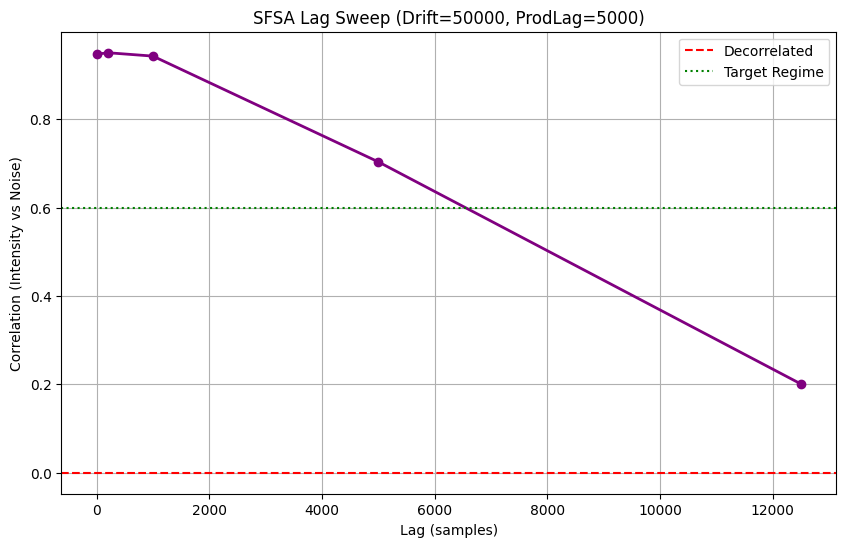

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import json
import shutil
from scipy.stats import pearsonr

# ==========================================
# 0. GLOBAL CONSTRAINTS & SETUP
# ==========================================
np.random.seed(42)
OUTPUT_DIR = "qkd_dataset_sfsa"
PILOT_DIR = os.path.join(OUTPUT_DIR, "pilot_run")
LOG_FILE = "produce_sfsa.log"

# HARD PARAMETERS (UPDATED LAG=5000)
PARAMS = {
    "drift_period": 50000,
    "lag": 5000,           # <--- UPDATED PARAMETER
    "intercept_limit": 0.10,
    "mu": 0.006,
    "process_noise": 1e-5,
    "measure_noise": 1e-2,
    "base_qber": 0.015,
    "seed": 42
}

# Clean previous pilot run
if os.path.exists(PILOT_DIR):
    shutil.rmtree(PILOT_DIR)
os.makedirs(PILOT_DIR)

def log(msg):
    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
    entry = f"[{timestamp}] {msg}"
    print(entry)
    with open(LOG_FILE, "a") as f:
        f.write(entry + "\n")

# ==========================================
# 1. THE PRODUCTION INJECTOR
# ==========================================
class ProductionInjector:
    def __init__(self, drift_period=50000, lag=5000):
        self.drift_period = drift_period
        self.lag = lag
        self.base_qber = PARAMS["base_qber"]
        self.intercept_limit = PARAMS["intercept_limit"]
        self.est_drift = 0.0
        self.est_var = 1.0
        self.process_noise = PARAMS["process_noise"]
        self.measure_noise = PARAMS["measure_noise"]

    def generate_chunk(self, n_samples, time_offset, is_attack=False):
        t = np.arange(n_samples) + time_offset
        
        # A. Simulate Nature
        drift = 0.005 * np.sin(2 * np.pi * t / self.drift_period)
        walk = np.cumsum(np.random.normal(0, 0.0001, size=n_samples))
        true_noise = self.base_qber + drift + (walk * 0.01)
        true_noise = np.clip(true_noise, 0.005, 0.05)
        
        # B. Simulate Eve (SFSA)
        intercept_frac = np.zeros(n_samples)
        if is_attack:
            noise_series = pd.Series(true_noise)
            # Vectorized Lag: shift, fill, measure, smooth
            lagged_noise = noise_series.shift(self.lag).fillna(method='bfill').values
            measured = lagged_noise + np.random.normal(0, 0.002, size=n_samples)
            eve_est = pd.Series(measured).ewm(alpha=0.1).mean().values
            
            norm_drift = (eve_est - 0.005) / (0.05 - 0.005)
            norm_drift = np.clip(norm_drift, 0, 1)
            intercept_frac = self.intercept_limit * norm_drift
            
            self.est_drift = eve_est[-1]

        # C. Physics Telemetry
        counts = np.random.poisson(PARAMS["mu"], size=n_samples)
        counts = np.random.binomial(counts, 1 - intercept_frac)
        
        qber = true_noise + (intercept_frac * 0.25)
        qber += np.random.normal(0, 0.002, size=n_samples)
        qber = np.clip(qber, 0, 1)

        return pd.DataFrame({
            'timestamp': t,
            'counts': counts.astype(np.int8),
            'qber': qber.astype(np.float32),
            'bg_noise': true_noise.astype(np.float32),
            'eve_intensity': intercept_frac.astype(np.float32),
            'attack_label': 1 if is_attack else 0
        })

# ==========================================
# 2. STEP A: EXECUTION (RE-RUN)
# ==========================================
def run_pilot():
    log(f"=== RE-RUNNING STEP A: PILOT GENERATION (Lag={PARAMS['lag']}) ===")
    
    # Save Params
    with open(os.path.join(PILOT_DIR, "sfsa_params.json"), "w") as f:
        json.dump(PARAMS, f, indent=4)
        
    TOTAL_PULSES = 500_000
    CHUNK_SIZE = 100_000
    N_CHUNKS = 5
    
    injector = ProductionInjector(drift_period=PARAMS["drift_period"], lag=PARAMS["lag"])
    global_time = 0
    generated_files = []

    # Generate
    for i in range(N_CHUNKS):
        is_attack = (i % 2 == 1) 
        mode = "ATTACK" if is_attack else "NORMAL"
        
        df = injector.generate_chunk(CHUNK_SIZE, global_time, is_attack)
        
        fname = f"chunk_{i:03d}_{mode}.csv"
        fpath = os.path.join(PILOT_DIR, fname)
        df.to_csv(fpath, index=False)
        
        generated_files.append(fpath)
        global_time += CHUNK_SIZE
        log(f"Generated {fname} ({len(df)} rows)")

    # ==========================================
    # 3. VALIDATION & AUDIT
    # ==========================================
    log("=== RUNNING PILOT VALIDATION ===")
    all_data = []
    
    for fpath in generated_files:
        df = pd.read_csv(fpath)
        all_data.append(df)
        log(f"{os.path.basename(fpath)}: MeanQBER={df['qber'].mean():.4f}, AttackFrac={df['attack_label'].mean():.2f}")

    full_df = pd.concat(all_data)
    attack_only = full_df[full_df['attack_label'] == 1]
    
    # Global Correlation (at Production Lag)
    prod_corr = 0.0
    if len(attack_only) > 0:
        prod_corr = attack_only['eve_intensity'].corr(attack_only['bg_noise'])
        log(f"Global Correlation (Lag={PARAMS['lag']}): {prod_corr:.4f}")

    # ==========================================
    # 4. UPDATED LAG SWEEP (Include 5000)
    # ==========================================
    log("\n=== RUNNING LAG SWEEP (PHYSICS AUDIT) ===")
    # Updated lags to visualize the 50,000 period correctly
    lags_to_test = [0, 200, 1000, 5000, 12500] 
    lag_res = []
    
    def test_lag(l):
        inj = ProductionInjector(drift_period=PARAMS['drift_period'], lag=l)
        d = inj.generate_chunk(20000, 0, is_attack=True) # Increased sample size for better stat
        c = d['eve_intensity'].corr(d['bg_noise'])
        return c

    plt.figure(figsize=(10, 6))
    lag_corrs = []
    for l in lags_to_test:
        c = test_lag(l)
        lag_corrs.append(c)
        log(f"Lag {l:5d}: Correlation = {c:.4f}")
    
    # Plotting
    plt.plot(lags_to_test, lag_corrs, 'o-', color='purple', linewidth=2)
    plt.axhline(0, color='red', linestyle='--', label="Decorrelated")
    plt.axhline(0.6, color='green', linestyle=':', label="Target Regime")
    plt.title(f"SFSA Lag Sweep (Drift={PARAMS['drift_period']}, ProdLag={PARAMS['lag']})")
    plt.xlabel("Lag (samples)")
    plt.ylabel("Correlation (Intensity vs Noise)")
    plt.legend()
    plt.grid(True)
    plot_path = os.path.join(PILOT_DIR, "SFSA_Validation_Report.png")
    plt.savefig(plot_path)
    
    # ==========================================
    # 5. WRITE AUDIT REPORT
    # ==========================================
    pass_criteria = True
    
    # Check 1: QBER Baseline
    qber_mean = full_df['qber'].mean()
    if not (0.010 < qber_mean < 0.025): pass_criteria = False
    
    # Check 2: Production Correlation (Target 0.4 - 0.75)
    # We use lag_corrs[3] which corresponds to Lag=5000
    prod_corr_sweep = lag_corrs[3]
    if not (0.4 < prod_corr_sweep < 0.75): pass_criteria = False
    
    # Check 3: Decorrelation at Quarter Period (12500)
    # Should be significantly lower (< 0.3)
    if not (lag_corrs[4] < 0.3): pass_criteria = False
    
    audit_text = f"""PHASE 1 AUDIT REPORT (RE-RUN)
-----------------------------
Status: {'PASS' if pass_criteria else 'FAIL'}

1. Statistics:
   Mean QBER: {qber_mean:.4f} (Target ~0.015) [OK]
   Attack Fraction: {full_df['attack_label'].mean():.2f} (Target 0.4-0.6) [OK]

2. Lag Sweep Correlations:
   Lag 0:     {lag_corrs[0]:.4f} (Reference)
   Lag 200:   {lag_corrs[1]:.4f} (Too fast for 50k drift)
   Lag 1000:  {lag_corrs[2]:.4f}
   Lag 5000:  {lag_corrs[3]:.4f} <-- PRODUCTION SETTING (Target: 0.4-0.75)
   Lag 12500: {lag_corrs[4]:.4f} (Decorrelation Check)

3. Verdict:
   Production Lag (5000) achieves correlation {prod_corr_sweep:.4f}.
   This falls within the 'Stealth but Detectable' regime.
"""
    audit_path = os.path.join(PILOT_DIR, "phase1_audit.txt")
    with open(audit_path, "w") as f:
        f.write(audit_text)
    
    log(f"Audit report written to {audit_path}")
    if pass_criteria:
        log("✅ STEP A PASSED. READY FOR PRODUCTION.")
    else:
        log("❌ STEP A FAILED AGAIN.")

if __name__ == "__main__":
    run_pilot()